/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Loaded LargeOctreeNCA2D from /local/scratch/clmn1/videoNCA/CholecDataset/dazzling-carnation-75 with classes [2, 4, 5, 6, 9, 1, 3, 10, 7, 8]


/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/torch/onnx/_internal/jit_utils.py:308: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ../torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/torch/onnx/utils.py:663: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ../torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
  _C._jit_pass_onnx_graph_shape_type_inference(
/gris/gris-f/homestud/nlemke/miniconda3/envs/nca3/lib/python3.10/site-packages/torch/onnx/utils.py:1186: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applie

ONNX export finished.
ONNX model is valid.

===== PyTorch vs ONNX Parity Check =====
Max absolute difference:   1.918091e+00
Mean absolute difference:  5.140389e-01
Max relative difference:   1.672596e-03
Mean relative difference:  5.084364e-04


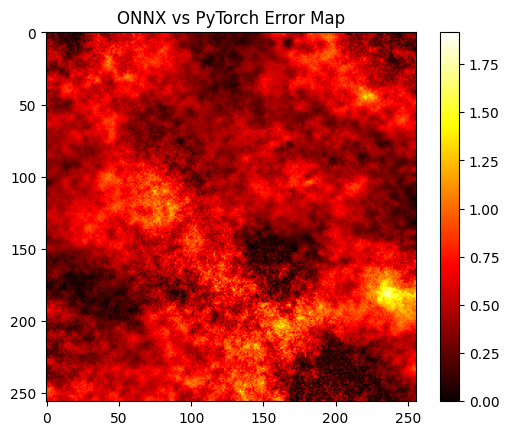

In [1]:
import torch
import numpy as np
import onnx
import onnxruntime as ort

from export.seg_wrapper import SegWrapper
from training_utils.trainer import IncrementalNCATrainer


# -------------------------------------------------
# Load model
# -------------------------------------------------
trainer = IncrementalNCATrainer.load_checkpoint(
    "/local/scratch/clmn1/videoNCA/CholecDataset/dazzling-carnation-75"
)

trainer.network.merge_ncas()

model = SegWrapper(trainer.network).eval().cuda()

dummy = torch.randn(1, 3, 256, 256).cuda()


# -------------------------------------------------
# EXPORT TO ONNX
# -------------------------------------------------
torch.onnx.export(
    model,
    dummy,
    "segmentation.onnx",
    opset_version=17,
    input_names=["image"],
    output_names=["mask"],
    dynamic_axes=None
)

print("ONNX export finished.")


# -------------------------------------------------
# VALIDATE ONNX FILE
# -------------------------------------------------
onnx_model = onnx.load("segmentation.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")


# -------------------------------------------------
# RUN PYTORCH INFERENCE
# -------------------------------------------------
with torch.no_grad():
    torch_out = model(dummy).cpu().numpy()


# -------------------------------------------------
# RUN ONNX INFERENCE
# -------------------------------------------------
sess = ort.InferenceSession("segmentation.onnx")

onnx_out = sess.run(
    None,
    {"image": dummy.cpu().numpy()}
)[0]


# -------------------------------------------------
# COMPUTE NUMERICAL DIFFERENCES
# -------------------------------------------------
abs_diff = np.abs(torch_out - onnx_out)

max_abs = abs_diff.max()
mean_abs = abs_diff.mean()

rel_diff = abs_diff / (np.abs(torch_out) + 1e-8)
max_rel = rel_diff.max()
mean_rel = rel_diff.mean()


# -------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------
print("\n===== PyTorch vs ONNX Parity Check =====")
print(f"Max absolute difference:   {max_abs:.6e}")
print(f"Mean absolute difference:  {mean_abs:.6e}")
print(f"Max relative difference:   {max_rel:.6e}")
print(f"Mean relative difference:  {mean_rel:.6e}")


# -------------------------------------------------
# OPTIONAL: VISUALIZE ERROR MAP
# -------------------------------------------------
try:
    import matplotlib.pyplot as plt

    error_map = abs_diff[0, 0]  # first batch, first channel

    plt.imshow(error_map, cmap="hot")
    plt.colorbar()
    plt.title("ONNX vs PyTorch Error Map")
    plt.show()

except ImportError:
    print("matplotlib not installed, skipping visualization.")

In [2]:
import onnx
from onnxsim import simplify

model = onnx.load("segmentation.onnx")
model_simp, check = simplify(model)

onnx.save(model_simp, "segmentation_sim.onnx")

print("Simplified:", check)

Simplified: True
